# Heart Disease Detection Model using ML & DL Algorithms

## **1. Importing Libraries**

In [ ]:
import os
import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Save models
import joblib

# Install/import XGBoost safely
try:
    from xgboost import XGBClassifier
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

# Install/import TensorFlow safely for Deep Learning models
try:
    import tensorflow as tf
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'])
    import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('Libraries imported successfully!')

Libraries imported successfully!


## **2. Loading Dataset**


In [ ]:
# Load dataset in Google Colab or local environment
possible_files = [
    'dataset_heart.csv',
    'dataset_heart(1).csv',
    '/mnt/data/dataset_heart.csv',
    '/mnt/data/dataset_heart(1).csv'
]

dataset_path = None
for file_path in possible_files:
    if os.path.exists(file_path):
        dataset_path = file_path
        break

# If file is not found, ask user to upload in Colab
if dataset_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        dataset_path = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError(
            "Dataset file not found. Please upload dataset_heart.csv to Colab and run this cell again."
        )

# Read CSV file
df = pd.read_csv(dataset_path)

print('Dataset loaded successfully!')
print('Dataset path:', dataset_path)

Dataset loaded successfully!
Dataset path: dataset_heart.csv


## **3. Dataset Description**





In [ ]:
print('Number of rows and columns:', df.shape)
print('\nDataset columns:')
print(df.columns.tolist())

print('\nStatistical description:')
display(df.describe())

Number of rows and columns: (270, 14)

Dataset columns:
['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal', 'heart disease']

Statistical description:


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


## 4. Data Inspection


In [ ]:
# Check shape
print('Dataset shape:', df.shape)

# Check columns
print('\nColumns:')
for i, col in enumerate(df.columns, start=1):
    print(f'{i}. {col}')

# Check data types
print('\nData types:')
print(df.dtypes)

# Show first 5 rows
print('\nFirst 5 rows:')
display(df.head())

# Check target column before cleaning
possible_target_names = ['heart disease', 'heart_disease', 'target', 'Target', 'TARGET']
found_targets = [col for col in df.columns if col in possible_target_names]
print('\nPossible target columns found:', found_targets)

Dataset shape: (270, 14)

Columns:
1. age
2. sex 
3. chest pain type
4. resting blood pressure
5. serum cholestoral
6. fasting blood sugar
7. resting electrocardiographic results
8. max heart rate
9. exercise induced angina
10. oldpeak
11. ST segment
12. major vessels
13. thal
14. heart disease

Data types:
age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral                         int64
fasting blood sugar                       int64
resting electrocardiographic results      int64
max heart rate                            int64
exercise induced angina                   int64
oldpeak                                 float64
ST segment                                int64
major vessels                             int64
thal                                      int64
heart disease                             int64
dtype: object

Firs

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1



Possible target columns found: ['heart disease']


## **5. Data Cleaning**



In [ ]:
# Make a copy for cleaning
heart_df = df.copy()

# Clean column names
heart_df.columns = (
    heart_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

# Fix common spelling issue in cholesterol column name
heart_df = heart_df.rename(columns={
    'serum_cholestoral': 'serum_cholesterol',
    'resting_electrocardiographic_results': 'resting_ecg',
    'exercise_induced_angina': 'exercise_angina'
})

print('Cleaned columns:')
print(heart_df.columns.tolist())

# Check missing values
print('\nMissing values in each column:')
print(heart_df.isnull().sum())

# Check duplicates
duplicate_count = heart_df.duplicated().sum()
print('\nDuplicate rows:', duplicate_count)

# Remove duplicates if present
if duplicate_count > 0:
    heart_df = heart_df.drop_duplicates().reset_index(drop=True)
    print('Duplicates removed. New shape:', heart_df.shape)
else:
    print('No duplicate rows found.')

# Identify target column
target_col = None
for col in ['heart_disease', 'target']:
    if col in heart_df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError('Target column not found. Please check the dataset column names.')

print('\nTarget column:', target_col)
print('Original target values:', sorted(heart_df[target_col].unique()))

# Convert target labels into 0 and 1
# Many heart disease datasets use: 1 = absence/no disease, 2 = presence/disease
if set(heart_df[target_col].unique()) == {1, 2}:
    heart_df[target_col] = heart_df[target_col].map({1: 0, 2: 1})
elif set(heart_df[target_col].unique()) == {0, 1}:
    heart_df[target_col] = heart_df[target_col].astype(int)
else:
    # Generic conversion if there are more than two labels
    heart_df[target_col] = (heart_df[target_col] > 0).astype(int)

print('Converted target values:', sorted(heart_df[target_col].unique()))
print('\nClass distribution after conversion:')
print(heart_df[target_col].value_counts())

Cleaned columns:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'serum_cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_segment', 'major_vessels', 'thal', 'heart_disease']

Missing values in each column:
age                       0
sex                       0
chest_pain_type           0
resting_blood_pressure    0
serum_cholesterol         0
fasting_blood_sugar       0
resting_ecg               0
max_heart_rate            0
exercise_angina           0
oldpeak                   0
st_segment                0
major_vessels             0
thal                      0
heart_disease             0
dtype: int64

Duplicate rows: 0
No duplicate rows found.

Target column: heart_disease
Original target values: [np.int64(1), np.int64(2)]
Converted target values: [np.int64(0), np.int64(1)]

Class distribution after conversion:
heart_disease
0    150
1    120
Name: count, dtype: int64


## **6. Exploratory Data Analysis — EDA**



### ***6.1 Target class distribution***

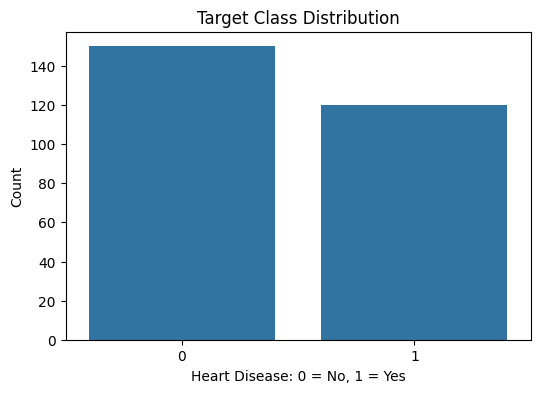

heart_disease
0    55.555556
1    44.444444
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=heart_df, x=target_col)
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease: 0 = No, 1 = Yes')
plt.ylabel('Count')
plt.show()

print(heart_df[target_col].value_counts(normalize=True) * 100)

### ***6.2 Age distribution***

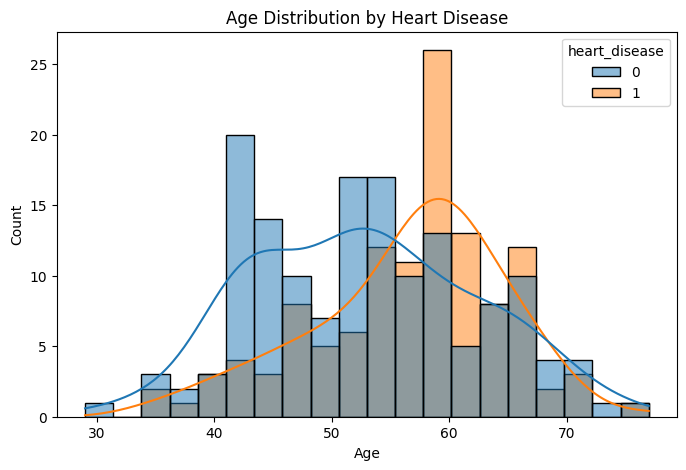

In [ ]:
age_col = 'age'

plt.figure(figsize=(8, 5))
sns.histplot(data=heart_df, x=age_col, hue=target_col, kde=True, bins=20)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### ***6.3 Gender-wise heart disease count***

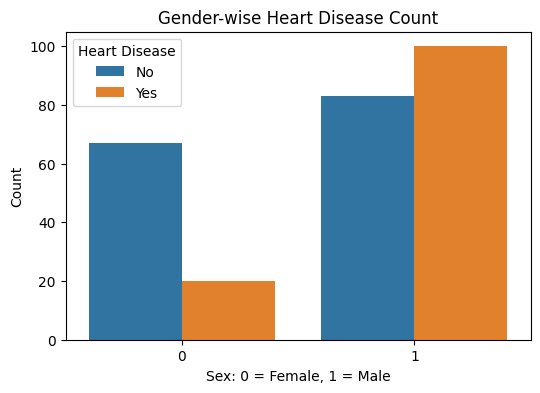

In [ ]:
if 'sex' in heart_df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=heart_df, x='sex', hue=target_col)
    plt.title('Gender-wise Heart Disease Count')
    plt.xlabel('Sex: 0 = Female, 1 = Male')
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
    plt.show()
else:
    print('Sex column not found.')

### ***6.4 Chest pain and heart disease relation***

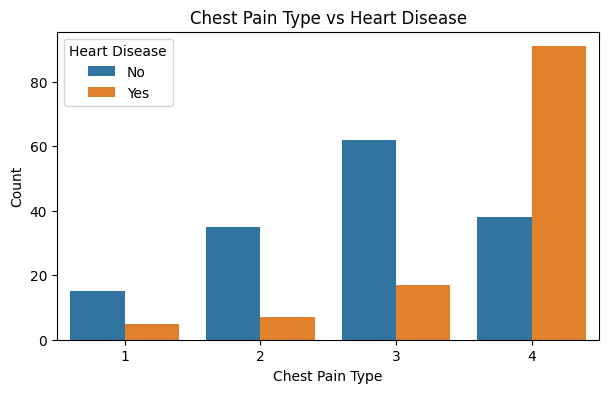

In [ ]:
if 'chest_pain_type' in heart_df.columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=heart_df, x='chest_pain_type', hue=target_col)
    plt.title('Chest Pain Type vs Heart Disease')
    plt.xlabel('Chest Pain Type')
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
    plt.show()
else:
    print('Chest pain type column not found.')

###  ***6.5 Cholesterol distribution***

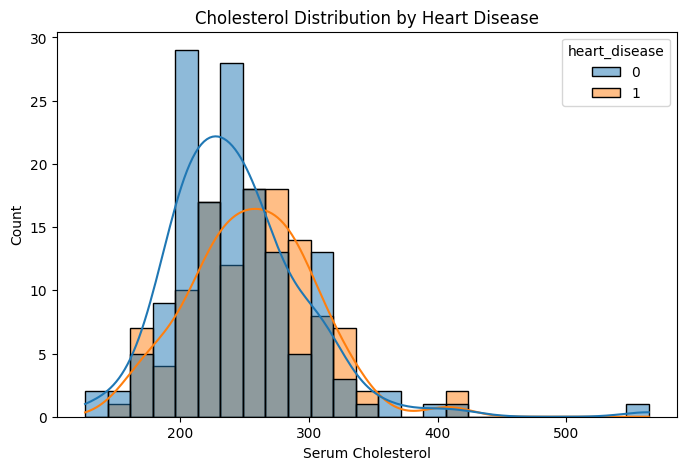

In [ ]:
cholesterol_col = 'serum_cholesterol'

if cholesterol_col in heart_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=heart_df, x=cholesterol_col, hue=target_col, kde=True, bins=25)
    plt.title('Cholesterol Distribution by Heart Disease')
    plt.xlabel('Serum Cholesterol')
    plt.ylabel('Count')
    plt.show()
else:
    print('Cholesterol column not found.')

### ***6.6 Correlation heatmap***

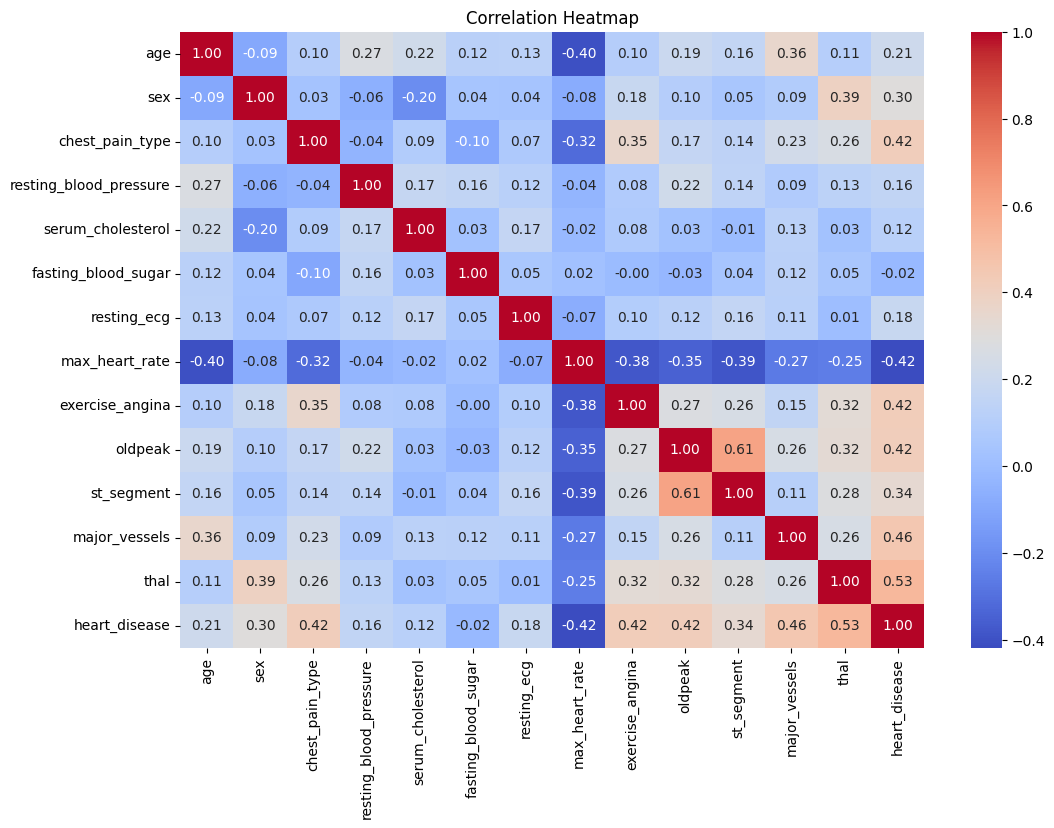

In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = heart_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **7. Feature Selection**


Feature matrix shape: (270, 13)
Target vector shape: (270,)

Correlation of features with target:


,heart_disease
heart_disease,1.000000
thal,0.525020
major_vessels,0.455336
exercise_angina,0.419303
oldpeak,0.417967
chest_pain_type,0.417436
st_segment,0.337616
sex,0.297721
age,0.212322
resting_ecg,0.182091


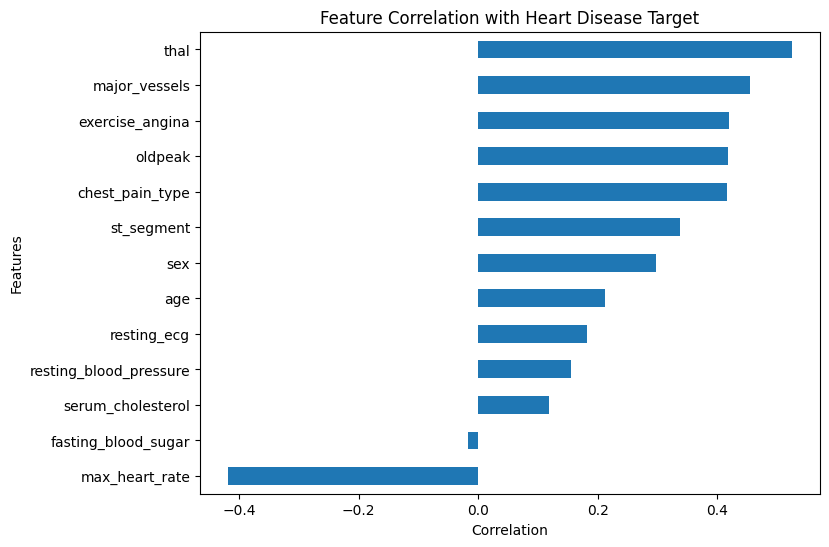

In [ ]:
# Separate features and target
X = heart_df.drop(columns=[target_col])
y = heart_df[target_col]

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

# Correlation with target
correlation_with_target = heart_df.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print('\nCorrelation of features with target:')
display(correlation_with_target)

# Plot correlation with target
plt.figure(figsize=(8, 6))
correlation_with_target.drop(target_col).sort_values().plot(kind='barh')
plt.title('Feature Correlation with Heart Disease Target')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

## **8. Data Splitting**


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

print('\nTraining class distribution:')
print(y_train.value_counts())

print('\nTesting class distribution:')
print(y_test.value_counts())

X_train shape: (216, 13)
X_test shape: (54, 13)
y_train shape: (216,)
y_test shape: (54,)

Training class distribution:
heart_disease
0    120
1     96
Name: count, dtype: int64

Testing class distribution:
heart_disease
0    30
1    24
Name: count, dtype: int64


## **9. Feature Scaling**


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed!')
print('Scaled training data shape:', X_train_scaled.shape)
print('Scaled testing data shape:', X_test_scaled.shape)

Feature scaling completed!
Scaled training data shape: (216, 13)
Scaled testing data shape: (54, 13)


## **10. Model Building**

1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Support Vector Classifier
4. Random Forest Classifier
5. XGBoost Classifier
6. Artificial Neural Network / MLP
7. Deep Neural Network

In [ ]:
# Build Machine Learning models
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Classifier': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    'XGBoost Classifier': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )
}

print('Machine Learning models created successfully!')

Machine Learning models created successfully!


In [ ]:
# Build Artificial Neural Network / MLP model
def build_ann_model(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.20),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build Deep Neural Network model
def build_dnn_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.30),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),
        Dense(16, activation='relu'),
        Dropout(0.20),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

input_dim = X_train_scaled.shape[1]
ann_model = build_ann_model(input_dim)
dnn_model = build_dnn_model(input_dim)

print('ANN / MLP model summary:')
ann_model.summary()

print('\nDNN model summary:')
dnn_model.summary()

ANN / MLP model summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

## 11. Model Training

Trains all Machine Learning and Deep Learning models.

In [ ]:
# Train Machine Learning models
trained_models = {}

for model_name, model in ml_models.items():
    print(f'Training {model_name}...')
    model.fit(X_train_scaled, y_train)
    trained_models[model_name] = model
    print(f'{model_name} training completed!')

print('\nAll Machine Learning models trained successfully!')

Training Logistic Regression...
Logistic Regression training completed!
Training K-Nearest Neighbors...
K-Nearest Neighbors training completed!
Training Support Vector Classifier...
Support Vector Classifier training completed!
Training Random Forest Classifier...
Random Forest Classifier training completed!
Training XGBoost Classifier...
XGBoost Classifier training completed!

All Machine Learning models trained successfully!


In [ ]:
# Train Deep Learning models
# Early stopping prevents overfitting on small datasets.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print('Training ANN / MLP model...')
ann_history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
print('ANN / MLP training completed!')

print('\nTraining DNN model...')
dnn_history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=120,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
print('DNN training completed!')

Training ANN / MLP model...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.5814 - loss: 0.7812 - val_accuracy: 0.4773 - val_loss: 0.7852
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5814 - loss: 0.6899 - val_accuracy: 0.4773 - val_loss: 0.7103
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6047 - loss: 0.6303 - val_accuracy: 0.5455 - val_loss: 0.6545
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6512 - loss: 0.5873 - val_accuracy: 0.6136 - val_loss: 0.6125
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6860 - loss: 0.5413 - val_accuracy: 0.6591 - val_loss: 0.5785
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7442 - loss: 0.5245 - val_accuracy: 0.7273 - val_loss: 0.5520
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7384 - loss: 0.4863 - val_accuracy: 0.7273 - val_loss: 0.5299
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8256 - loss: 0.

## **12. Model Evaluation**

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report

In [ ]:
# Helper function for model evaluation
def evaluate_predictions(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print('=' * 70)
    print(model_name)
    print('=' * 70)
    print('Accuracy :', round(accuracy, 4))
    print('Precision:', round(precision, 4))
    print('Recall   :', round(recall, 4))
    print('F1-score :', round(f1, 4))
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['No Heart Disease', 'Heart Disease'], zero_division=0))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

results = []
predictions = {}

# Evaluate ML models
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[model_name] = y_pred
    result = evaluate_predictions(model_name, y_test, y_pred)
    results.append(result)

# Evaluate ANN / MLP
ann_prob = ann_model.predict(X_test_scaled).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)
predictions['Artificial Neural Network / MLP'] = ann_pred
results.append(evaluate_predictions('Artificial Neural Network / MLP', y_test, ann_pred))

# Evaluate DNN
dnn_prob = dnn_model.predict(X_test_scaled).ravel()
dnn_pred = (dnn_prob >= 0.5).astype(int)
predictions['Deep Neural Network'] = dnn_pred
results.append(evaluate_predictions('Deep Neural Network', y_test, dnn_pred))

Logistic Regression
Accuracy : 0.8519
Precision: 0.7857
Recall   : 0.9167
F1-score : 0.8462

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.80      0.86        30
   Heart Disease       0.79      0.92      0.85        24

        accuracy                           0.85        54
       macro avg       0.85      0.86      0.85        54
    weighted avg       0.86      0.85      0.85        54

K-Nearest Neighbors
Accuracy : 0.7963
Precision: 0.7241
Recall   : 0.875
F1-score : 0.7925

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.88      0.73      0.80        30
   Heart Disease       0.72      0.88      0.79        24

        accuracy                           0.80        54
       macro avg       0.80      0.80      0.80        54
    weighted avg       0.81      0.80      0.80        54

Support Vector Classifier
Accuracy : 0.8148
Precision: 0.7692
Recal

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Artificial Neural Network / MLP
Accuracy : 0.8519
Precision: 0.7857
Recall   : 0.9167
F1-score : 0.8462

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.80      0.86        30
   Heart Disease       0.79      0.92      0.85        24

        accuracy                           0.85        54
       macro avg       0.85      0.86      0.85        54
    weighted avg       0.86      0.85      0.85        54

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
Deep Neural Network
Accuracy : 0.537
Precision: 0.4894
Recall   : 0.9583
F1-score : 0.6479

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.86      0.20      0.32        30
   Heart Disease       0.49      0.96      0.65        24

        accuracy                           0.54        54
       macro avg       0.67      0.58      0.49        54
    weighted avg       0.69      0.5

## **13. Confusion Matrix**


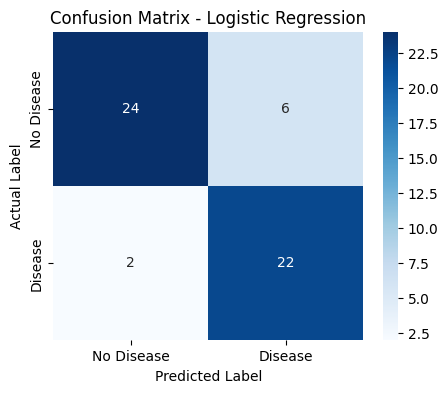

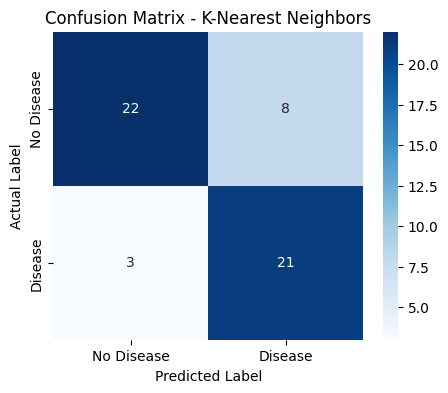

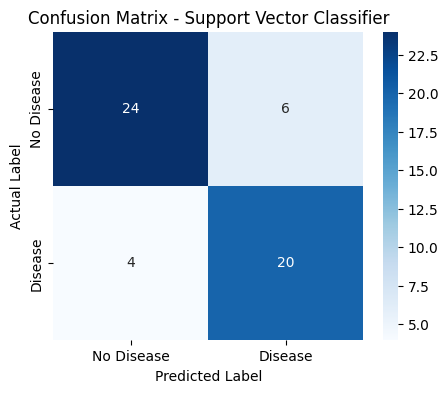

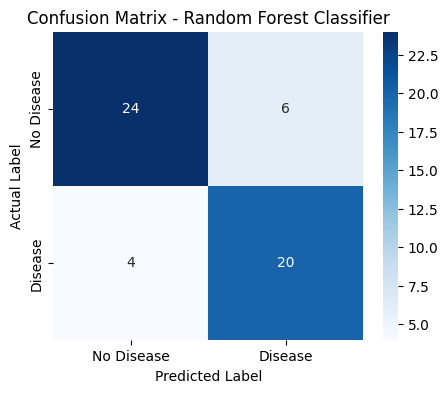

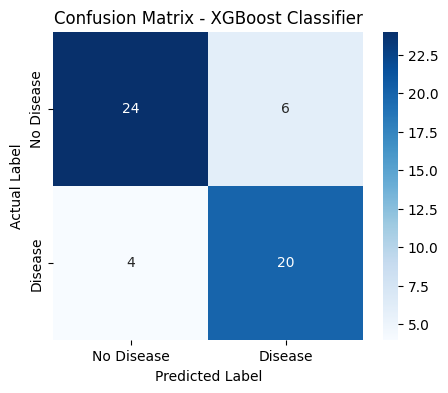

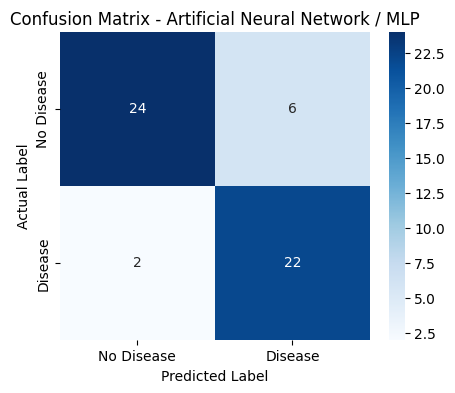

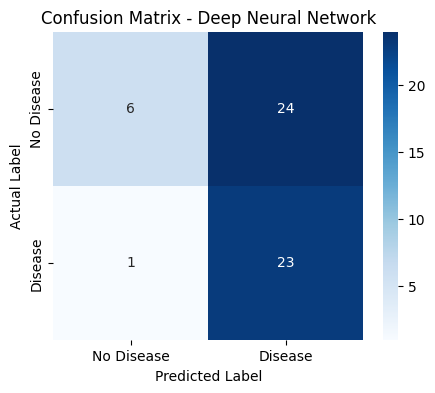

In [ ]:
for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease']
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

## 15. Performance Comparison

Compares all models using Accuracy and F1-score.

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.851852,0.785714,0.916667,0.846154
1,Artificial Neural Network / MLP,0.851852,0.785714,0.916667,0.846154
2,Support Vector Classifier,0.814815,0.769231,0.833333,0.800000
3,XGBoost Classifier,0.814815,0.769231,0.833333,0.800000
4,Random Forest Classifier,0.814815,0.769231,0.833333,0.800000
5,K-Nearest Neighbors,0.796296,0.724138,0.875000,0.792453
6,Deep Neural Network,0.537037,0.489362,0.958333,0.647887


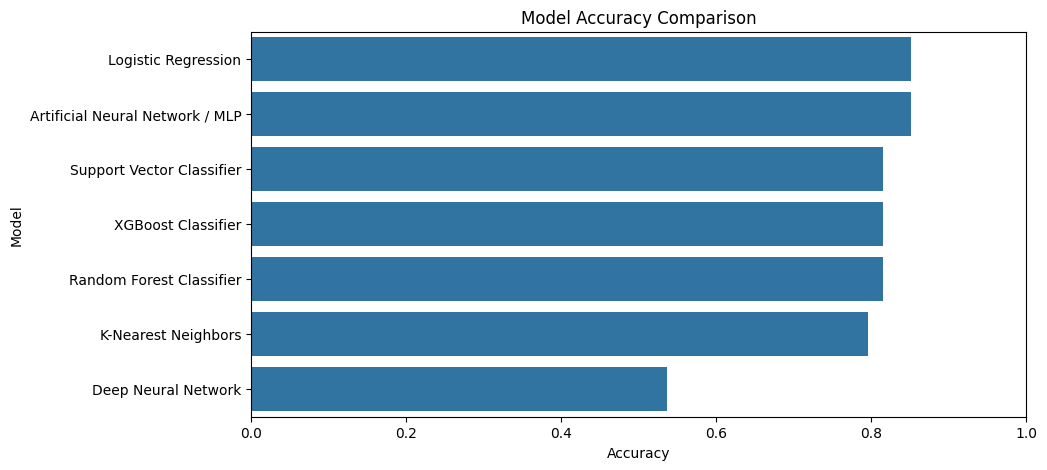

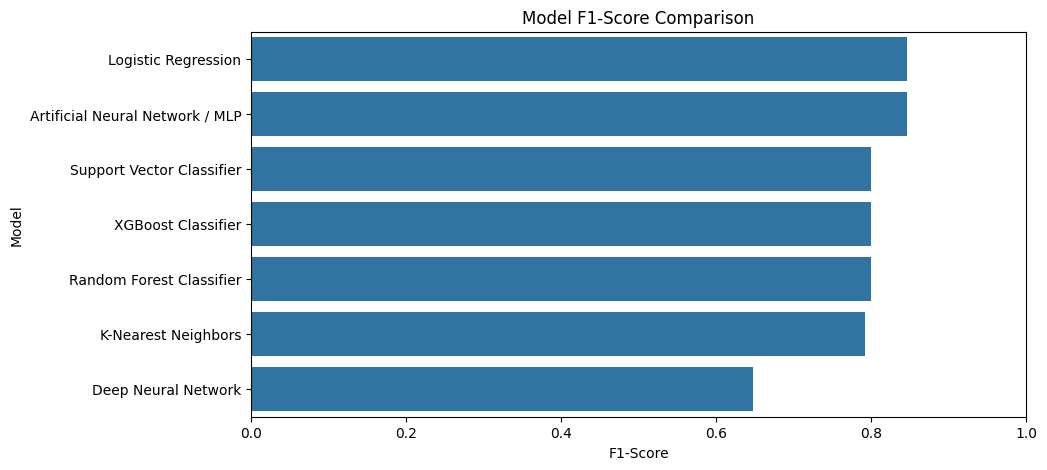

Best Accuracy Model: Logistic Regression
Accuracy: 0.8519


In [ ]:
# Create performance comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print('Model Performance Comparison:')
display(results_df)

# Accuracy comparison bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Accuracy', y='Model')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

# F1-score comparison bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='F1-Score', y='Model')
plt.title('Model F1-Score Comparison')
plt.xlabel('F1-Score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

best_model = results_df.iloc[0] if results_df.columns[1] == 'F1-Score' else results_df.loc[results_df['Accuracy'].idxmax()]

print(f"Best Accuracy Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")

## **15. Feature Importance Analysis**

Feature importance helps us understand which medical features are most useful for prediction.


Random Forest Feature Importance:


,Feature,Importance
2,chest_pain_type,0.129869
7,max_heart_rate,0.115767
12,thal,0.115471
11,major_vessels,0.106665
9,oldpeak,0.103620
4,serum_cholesterol,0.090181
0,age,0.087755
3,resting_blood_pressure,0.077605
10,st_segment,0.056996
8,exercise_angina,0.046926


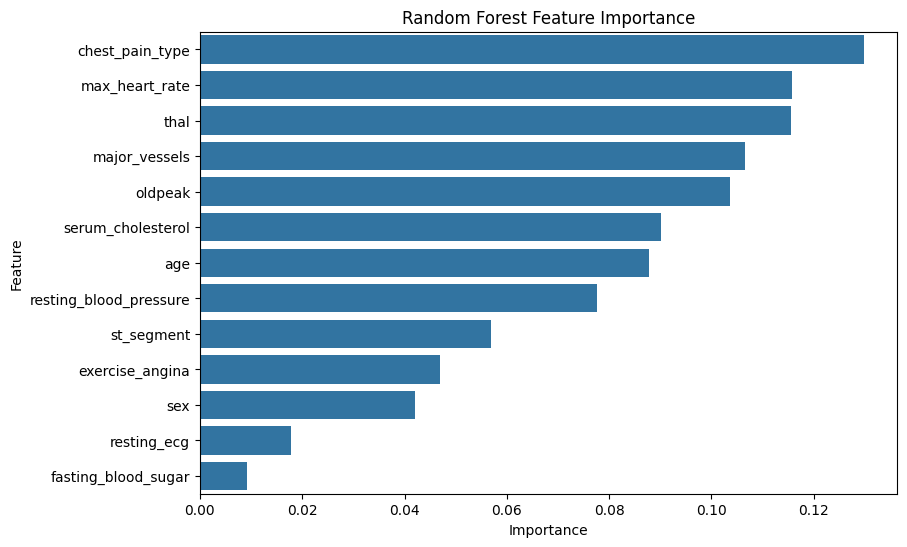

In [ ]:
# Random Forest feature importance
rf_model = trained_models['Random Forest Classifier']
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('Random Forest Feature Importance:')
display(rf_importance)

plt.figure(figsize=(9, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

XGBoost Feature Importance:


,Feature,Importance
12,thal,0.210765
2,chest_pain_type,0.175417
11,major_vessels,0.120070
8,exercise_angina,0.079421
9,oldpeak,0.071145
10,st_segment,0.068276
1,sex,0.055238
4,serum_cholesterol,0.044112
3,resting_blood_pressure,0.042227
7,max_heart_rate,0.042182


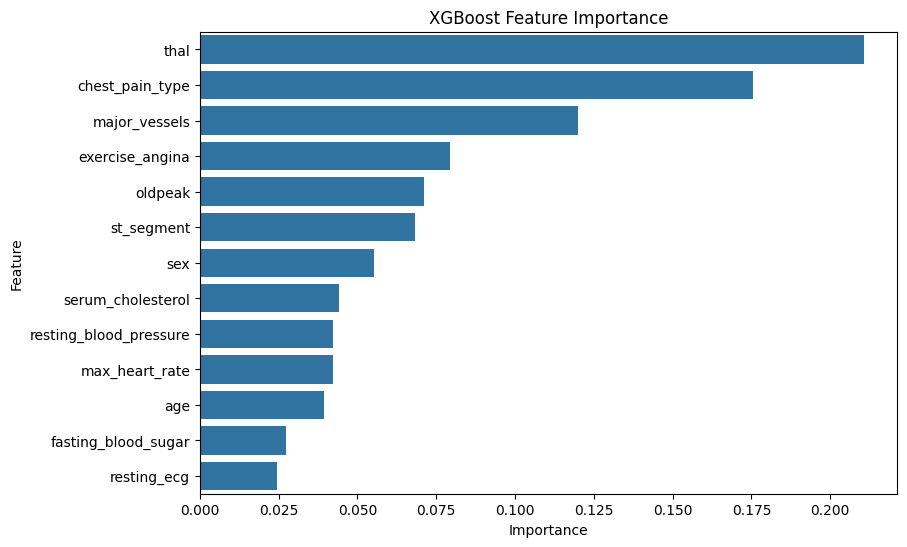

In [ ]:
# XGBoost feature importance
xgb_model = trained_models['XGBoost Classifier']
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('XGBoost Feature Importance:')
display(xgb_importance)

plt.figure(figsize=(9, 6))
sns.barplot(data=xgb_importance, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## **16. Prediction System**



In [ ]:
# Select best model based on F1-score
best_model_name = results_df.iloc[0]['Model']
print('Best model based on F1-score:', best_model_name)

# Create sample patient data using first test record
sample_patient = X_test.iloc[[0]].copy()
print('\nSample patient data:')
display(sample_patient)

# Scale sample patient data
sample_patient_scaled = scaler.transform(sample_patient)

# Prediction using best model
if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
    sample_prediction = best_model.predict(sample_patient_scaled)[0]
elif best_model_name == 'Artificial Neural Network / MLP':
    sample_prediction = int((ann_model.predict(sample_patient_scaled).ravel()[0] >= 0.5))
elif best_model_name == 'Deep Neural Network':
    sample_prediction = int((dnn_model.predict(sample_patient_scaled).ravel()[0] >= 0.5))
else:
    raise ValueError('Best model not found.')

print('\nPrediction Result:')
if sample_prediction == 1:
    print('The model predicts: Heart Disease Detected')
else:
    print('The model predicts: No Heart Disease Detected')

Best model based on F1-score: Logistic Regression

Sample patient data:


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_segment,major_vessels,thal
195,55,0,2,135,250,0,2,161,0,1.4,2,0,3



Prediction Result:
The model predicts: No Heart Disease Detected


In [ ]:
# Manual Testing on Custom Patient Data
manual_patient = {
    'age': 65,
    'sex': 1,
    'chest_pain_type': 3,
    'resting_blood_pressure': 170,
    'serum_cholesterol': 320,
    'fasting_blood_sugar': 1,
    'resting_ecg': 2,
    'max_heart_rate': 110,
    'exercise_angina': 1,
    'oldpeak': 4.0,
    'st_segment': 0,
    'major_vessels': 3,
    'thal': 3
}

# Convert to DataFrame
manual_patient_df = pd.DataFrame([manual_patient])

# Scale the data
manual_patient_scaled = scaler.transform(manual_patient_df)

# Predict using the best model
if best_model_name in trained_models:
    manual_prediction = trained_models[best_model_name].predict(
        manual_patient_scaled
    )[0]

elif best_model_name == 'Artificial Neural Network / MLP':
    manual_prediction = int(
        ann_model.predict(manual_patient_scaled).ravel()[0] > 0.5
    )

else:
    manual_prediction = int(
        dnn_model.predict(manual_patient_scaled).ravel()[0] > 0.5
    )

# Display Input Data
print("=" * 40)
print("MANUAL PATIENT DATA")
print("=" * 40)
display(manual_patient_df)

# Display Prediction
print("\n" + "=" * 40)
print("PREDICTION RESULT")
print("=" * 40)

if manual_prediction == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

MANUAL PATIENT DATA


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_segment,major_vessels,thal
0,65,1,3,170,320,1,2,110,1,4.0,0,3,3



PREDICTION RESULT
Heart Disease Detected


## **17. Save Model**


In [ ]:
# Create output folder
output_dir = 'heart_disease_prediction_outputs'
os.makedirs(output_dir, exist_ok=True)

# Save scaler
scaler_path = os.path.join(output_dir, 'standard_scaler.pkl')
joblib.dump(scaler, scaler_path)

# Save all ML models
for model_name, model in trained_models.items():
    clean_name = model_name.lower().replace(' ', '_').replace('/', '').replace('-', '_')
    model_path = os.path.join(output_dir, f'{clean_name}.pkl')
    joblib.dump(model, model_path)

# Save deep learning models
ann_model_path = os.path.join(output_dir, 'ann_mlp_model.h5')
dnn_model_path = os.path.join(output_dir, 'deep_neural_network_model.h5')
ann_model.save(ann_model_path)
dnn_model.save(dnn_model_path)

# Save performance results
results_path = os.path.join(output_dir, 'model_performance_results.csv')
results_df.to_csv(results_path, index=False)

# Save best model information
best_info_path = os.path.join(output_dir, 'best_model_info.txt')
with open(best_info_path, 'w') as f:
    f.write(f'Best Model: {best_model_name}\n')
    f.write(str(results_df.iloc[0].to_dict()))

print('Files saved successfully in folder:', output_dir)
print('Saved scaler:', scaler_path)
print('Saved ANN model:', ann_model_path)
print('Saved DNN model:', dnn_model_path)
print('Saved results:', results_path)

Files saved successfully in folder: heart_disease_prediction_outputs
Saved scaler: heart_disease_prediction_outputs/standard_scaler.pkl
Saved ANN model: heart_disease_prediction_outputs/ann_mlp_model.h5
Saved DNN model: heart_disease_prediction_outputs/deep_neural_network_model.h5
Saved results: heart_disease_prediction_outputs/model_performance_results.csv


## **18. Conclusion**


In [ ]:
# Best Model
best_row = results_df.iloc[0]
print(f"Best Performing Model: {best_row['Model']}")
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1-Score : {best_row['F1-Score']:.4f}")


Best Performing Model: Logistic Regression
Accuracy : 0.8519
Precision: 0.7857
Recall   : 0.9167
F1-Score : 0.8462
